In [2]:
import numpy as np
import math
import time
import json
import warnings
from itertools import permutations
from collections import defaultdict

# ── Qiskit core & simulator imports ──
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer.primitives import EstimatorV2 as AerEstimator, SamplerV2 as AerSampler
from scipy.optimize import minimize

warnings.filterwarnings('ignore')

# ── Configuration Flags ──
USE_REAL_HARDWARE = False  # True = run on IBM QPU
USE_AER_FOR_OPT   = True     # True = optimize on simulator (fast), false = optimize on QPU (Session)
USE_GPU_AER       = False     # True = try GPU-accelerated Aer; falls back to CPU if unavailable
                              # Requires: pip install qiskit-aer-gpu-cu11>=0.17
                              # (works on both CUDA 11 & 12 — the CUDA 12 package lacks a Qiskit 2.0 build)

# ── GPU Aer Options (shared across estimator & sampler) ──
_aer_gpu_options = {}
if USE_GPU_AER:
    try:
        from qiskit_aer import AerSimulator
        from qiskit import QuantumCircuit as _QC
        # Run a trivial 1-qubit circuit to verify GPU actually works
        # (AerSimulator init succeeds even without GPU — the error comes at runtime)
        _test_sim = AerSimulator(method='statevector', device='GPU')
        _test_qc = _QC(1); _test_qc.h(0); _test_qc.save_statevector()
        _test_sim.run(_test_qc).result()
        del _test_sim, _test_qc
        _aer_gpu_options = {'backend_options': {'device': 'GPU', 'method': 'statevector'}}
        print("Aer: GPU backend verified")
    except Exception as e:
        _aer_gpu_options = {}
        print(f"Aer GPU unavailable ({e}), falling back to CPU")

# ── Hardware Configuration ──
if USE_REAL_HARDWARE:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, Session, EstimatorV2
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    # First time only (run ONCE, then comment out)
    # QiskitRuntimeService.save_account(
    #     token="YOUR_IBM_QUANTUM_API_TOKEN",
    #     instance="YOUR_CRN_OR_INSTANCE_NAME",
    #     name="my_account",
    #     set_as_default=True,
    #     overwrite=True
    # )

    service = QiskitRuntimeService(name="my_account")
    backend = service.least_busy(min_num_qubits=16, operational=True)
    pm = generate_preset_pass_manager(optimization_level=2, backend=backend, translation_method="translator")
    print(f"Connected to: {backend.name}")
else:
    backend = None
    pm = None

# ── Utility Functions ──
def euclidean_distance(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

def build_distance_matrix(nodes):
    n = len(nodes)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i,j] = euclidean_distance(nodes[i], nodes[j])
    return D

def expectation_from_counts(counts, hamiltonian):
    """Compute <H> manually from counts (needed if optimizing on QPU)."""
    total = sum(counts.values())
    if total == 0:
        return 0.0
    exp_val = 0.0
    for pauli, coeff in zip(hamiltonian.paulis, hamiltonian.coeffs):
        label = pauli.to_label()
        z_positions = [i for i, c in enumerate(label) if c == 'Z']
        if not z_positions:
            exp_val += coeff.real
            continue
        term_exp = 0.0
        for bitstring, count in counts.items():
            eigenvalue = 1
            for pos in z_positions:
                eigenvalue *= (-1) ** int(bitstring[pos])
            term_exp += eigenvalue * count / total
        exp_val += coeff.real * term_exp
    return float(np.real(exp_val))


In [3]:
# ── Phase 1: Sweep Algorithm (Classical Clustering) ──

def sweep_decomposition(nodes, Nv, C, n_angles=16):
    """Cluster customers by polar angle from depot, trying multiple starting angles.
    Picks the best rotation using nearest-neighbor TSP estimate (scalable)."""
    depot = nodes[0]
    D_local = build_distance_matrix(nodes)

    # Precompute polar angles for all customers
    customer_angles = []
    for i in range(1, len(nodes)):
        angle = math.atan2(nodes[i][1] - depot[1], nodes[i][0] - depot[0])
        customer_angles.append((i, angle))

    best_clusters = None
    best_cost = float('inf')

    for k in range(n_angles):
        offset = 2 * math.pi * k / n_angles

        # Sort by shifted angle
        shifted = sorted(customer_angles,
                         key=lambda x: (x[1] - offset) % (2 * math.pi))

        # Pack into clusters respecting capacity
        clusters = []
        for start in range(0, len(shifted), C):
            if len(clusters) < Nv:
                chunk = shifted[start : start + C]
                clusters.append([c[0] for c in chunk])

        # Evaluate with nearest-neighbor TSP heuristic — O(n²) per cluster
        cost = 0
        for cluster in clusters:
            if len(cluster) == 1:
                cost += 2 * D_local[0, cluster[0]]
            else:
                visited = []
                current = 0  # start at depot
                remaining = set(cluster)
                while remaining:
                    nearest = min(remaining, key=lambda c: D_local[current, c])
                    cost += D_local[current, nearest]
                    current = nearest
                    remaining.remove(nearest)
                cost += D_local[current, 0]  # return to depot

        if cost < best_cost:
            best_cost = cost
            best_clusters = clusters

    return best_clusters

def clarke_wright_clusters(nodes, Nv, C):
    """Cluster customers using Clarke & Wright savings algorithm.
    Returns list of clusters (same format as sweep_decomposition)."""
    n = len(nodes)
    D = build_distance_matrix(nodes)

    # 1. Start: every customer gets its own route
    routes = [[i] for i in range(1, n)]

    # 2. Compute savings for all pairs: s(i,j) = D[0,i] + D[0,j] - D[i,j]
    savings = []
    for i in range(1, n):
        for j in range(i + 1, n):
            s = D[0, i] + D[0, j] - D[i, j]
            if s > 0:
                savings.append((s, i, j))
    savings.sort(reverse=True, key=lambda x: x[0])

    # 3. Greedily merge routes by highest savings
    def find_route(cust):
        for idx, r in enumerate(routes):
            if cust in r:
                return idx
        return -1

    for s, i, j in savings:
        ri, rj = find_route(i), find_route(j)

        # Must be different routes
        if ri == rj:
            continue

        # Both must be at the edge (first or last) of their route
        r_i, r_j = routes[ri], routes[rj]
        if not (r_i[0] == i or r_i[-1] == i):
            continue
        if not (r_j[0] == j or r_j[-1] == j):
            continue

        # Capacity check
        if len(r_i) + len(r_j) > C:
            continue

        # Orient and merge: make i the tail of r_i, j the head of r_j
        if r_i[-1] == i and r_j[0] == j:
            merged = r_i + r_j
        elif r_i[-1] == i and r_j[-1] == j:
            merged = r_i + r_j[::-1]
        elif r_i[0] == i and r_j[0] == j:
            merged = r_i[::-1] + r_j
        elif r_i[0] == i and r_j[-1] == j:
            merged = r_j + r_i
        else:
            continue

        # Apply merge
        for idx in sorted([ri, rj], reverse=True):
            routes.pop(idx)
        routes.append(merged)

    # 4. If too many routes remain, force-merge the cheapest pairs
    while len(routes) > Nv:
        best_cost, best_pair = float('inf'), None
        for a in range(len(routes)):
            for b in range(a + 1, len(routes)):
                if len(routes[a]) + len(routes[b]) <= C:
                    cost = D[routes[a][-1], routes[b][0]] - D[routes[a][-1], 0] - D[0, routes[b][0]]
                    if cost < best_cost:
                        best_cost = cost
                        best_pair = (a, b)
        if best_pair:
            a, b = best_pair
            routes[a] = routes[a] + routes[b]
            routes.pop(b)
        else:
            break

    return routes

def agglomerative_clusters(nodes, Nv, C):
    """Capacitated agglomerative clustering — merges by route cost reduction."""
    n = len(nodes)
    D = build_distance_matrix(nodes)
    clusters = [[i] for i in range(1, n)]

    def nn_cost(cluster):
        """Nearest-neighbor tour cost: depot → cluster → depot."""
        if len(cluster) == 1:
            return 2 * D[0, cluster[0]]
        cost, current, remaining = 0, 0, set(cluster)
        while remaining:
            nxt = min(remaining, key=lambda c: D[current, c])
            cost += D[current, nxt]
            current = nxt
            remaining.remove(nxt)
        return cost + D[current, 0]

    while len(clusters) > 1:
        best_benefit, best_pair = -float('inf'), None

        for a in range(len(clusters)):
            for b in range(a + 1, len(clusters)):
                if len(clusters[a]) + len(clusters[b]) > C:
                    continue
                benefit = nn_cost(clusters[a]) + nn_cost(clusters[b]) - nn_cost(clusters[a] + clusters[b])
                if benefit > best_benefit:
                    best_benefit = benefit
                    best_pair = (a, b)

        if best_pair is None:
            break  # No valid merges (capacity)
        if best_benefit <= 0 and len(clusters) <= Nv:
            break  # No benefit and within vehicle limit

        a, b = best_pair
        clusters[a] = clusters[a] + clusters[b]
        clusters.pop(b)

    return clusters


In [4]:
def nn_route_cost(cluster, nodes):
    """Nearest-neighbor route cost for a cluster (depot=0)."""
    if not cluster:
        return 0
    route = [0]
    remaining = list(cluster)
    while remaining:
        last = route[-1]
        nearest = min(remaining, key=lambda c: math.sqrt(
            (nodes[last][0]-nodes[c][0])**2 + (nodes[last][1]-nodes[c][1])**2))
        route.append(nearest)
        remaining.remove(nearest)
    # Return to depot
    cost = sum(math.sqrt((nodes[route[i]][0]-nodes[route[i+1]][0])**2 +
                          (nodes[route[i]][1]-nodes[route[i+1]][1])**2)
               for i in range(len(route)-1))
    cost += math.sqrt((nodes[route[-1]][0]-nodes[0][0])**2 +
                       (nodes[route[-1]][1]-nodes[0][1])**2)
    return cost

def two_opt_cost(cluster, nodes):
    """2-opt improved tour cost. O(C²) — scales to any C."""
    if not cluster or len(cluster) <= 1:
        c = cluster[0] if cluster else 0
        return 2 * math.sqrt((nodes[0][0]-nodes[c][0])**2 + (nodes[0][1]-nodes[c][1])**2) if cluster else 0

    def d(a, b):
        return math.sqrt((nodes[a][0]-nodes[b][0])**2 + (nodes[a][1]-nodes[b][1])**2)

    # Start with NN tour
    route = [0]
    remaining = list(cluster)
    while remaining:
        last = route[-1]
        nearest = min(remaining, key=lambda c: d(last, c))
        route.append(nearest)
        remaining.remove(nearest)
    route.append(0)

    # 2-opt improvement
    improved = True
    while improved:
        improved = False
        for i in range(1, len(route) - 2):
            for j in range(i + 1, len(route) - 1):
                old = d(route[i-1], route[i]) + d(route[j], route[j+1])
                new = d(route[i-1], route[j]) + d(route[i], route[j+1])
                if new < old - 1e-10:
                    route[i:j+1] = reversed(route[i:j+1])
                    improved = True

    return sum(d(route[k], route[k+1]) for k in range(len(route)-1))


def refine_clusters_swap(clusters, nodes, C, func):
    """Improve clusters via inter-cluster pairwise swaps."""
    clusters = [list(c) for c in clusters]
    improved = True
    iteration = 0
    
    while improved:
        improved = False
        iteration += 1
        
        for i in range(len(clusters)):
            for j in range(i+1, len(clusters)):
                old_cost = func(clusters[i], nodes) + func(clusters[j], nodes)
                
                # Try swaps: exchange customer a from cluster i with customer b from cluster j
                best_gain = 0
                best_swap = None
                
                for ai, a in enumerate(clusters[i]):
                    for bi, b in enumerate(clusters[j]):
                        # Swap
                        ci_new = clusters[i][:ai] + [b] + clusters[i][ai+1:]
                        cj_new = clusters[j][:bi] + [a] + clusters[j][bi+1:]
                        
                        if len(ci_new) > C or len(cj_new) > C:
                            continue
                        
                        new_cost = func(ci_new, nodes) + func(cj_new, nodes)
                        gain = old_cost - new_cost
                        
                        if gain > best_gain:
                            best_gain = gain
                            best_swap = (ai, bi, ci_new, cj_new)
                
                # Try moves: move customer from larger to smaller cluster
                for ai, a in enumerate(clusters[i]):
                    if len(clusters[j]) < C:
                        ci_new = clusters[i][:ai] + clusters[i][ai+1:]
                        cj_new = clusters[j] + [a]
                        if ci_new:  # don't empty a cluster
                            new_cost = func(ci_new, nodes) + func(cj_new, nodes)
                            gain = old_cost - new_cost
                            if gain > best_gain:
                                best_gain = gain
                                best_swap = (-1, -1, ci_new, cj_new)
                
                for bi, b in enumerate(clusters[j]):
                    if len(clusters[i]) < C:
                        cj_new = clusters[j][:bi] + clusters[j][bi+1:]
                        ci_new = clusters[i] + [b]
                        if cj_new:
                            new_cost = func(ci_new, nodes) + func(cj_new, nodes)
                            gain = old_cost - new_cost
                            if gain > best_gain:
                                best_gain = gain
                                best_swap = (-1, -1, ci_new, cj_new)
                
                if best_swap and best_gain > 1e-10:
                    clusters[i] = best_swap[2]
                    clusters[j] = best_swap[3]
                    improved = True
                    print(f"  Swap iter {iteration}: clusters {i},{j} improved by {best_gain:.2f}")
    
    print(f"  Swap refinement done in {iteration} iterations")
    return clusters


In [5]:
# ── Phase 2: TSP via QAOA (Quantum Routing) ──

def build_tsp_qubo(cluster_indices, dist_matrix):
    """Build upper-triangular QUBO for TSP (position formulation).
    Variables x[i,s] = 1 if cluster node i is at route position s.
    n customers → n² binary variables / qubits."""
    n = len(cluster_indices)
    N = n * n
    Q = np.zeros((N, N))
    idx = lambda i, s: i * n + s

    # Penalty coefficient (must dominate route costs)
    max_d = max(dist_matrix[a, b]
                for a in [0] + cluster_indices
                for b in [0] + cluster_indices if a != b)
    A = max_d * n * 1.5

    # Constraint: each customer visited exactly once  Σ_s x[i,s] = 1
    for i in range(n):
        for s in range(n):
            Q[idx(i,s), idx(i,s)] -= A
        for s in range(n):
            for t in range(s+1, n):
                Q[idx(i,s), idx(i,t)] += 2 * A

    # Constraint: each position filled by exactly one customer  Σ_i x[i,s] = 1
    for s in range(n):
        for i in range(n):
            Q[idx(i,s), idx(i,s)] -= A
        for i in range(n):
            for j in range(i+1, n):
                Q[idx(i,s), idx(j,s)] += 2 * A

    # Objective: route distance (depot → pos 0, transitions, pos n-1 → depot)
    for i, ci in enumerate(cluster_indices):
        Q[idx(i,0), idx(i,0)]     += dist_matrix[0, ci]   # depot → first
        Q[idx(i,n-1), idx(i,n-1)] += dist_matrix[ci, 0]   # last → depot
        for j, cj in enumerate(cluster_indices):
            if i != j:
                for s in range(n - 1):
                    a, b = idx(i, s), idx(j, s+1)
                    if a <= b:
                        Q[a, b] += dist_matrix[ci, cj]
                    else:
                        Q[b, a] += dist_matrix[ci, cj]
    return Q


def qubo_to_ising(Q):
    """Convert upper-triangular QUBO matrix to a SparsePauliOp Ising Hamiltonian.
    x_k = (1 - Z_k) / 2"""
    n = Q.shape[0]
    constant = 0.0
    h = np.zeros(n)
    J = {}

    for k in range(n):
        constant += Q[k, k] / 2.0
        h[k]     -= Q[k, k] / 2.0

    for k in range(n):
        for l in range(k+1, n):
            if abs(Q[k, l]) > 1e-12:
                constant += Q[k, l] / 4.0
                h[k]     -= Q[k, l] / 4.0
                h[l]     -= Q[k, l] / 4.0
                J[(k, l)] = Q[k, l] / 4.0

    # Build Pauli list  (qiskit little-endian: rightmost char = qubit 0)
    pauli_list = []
    for k in range(n):
        if abs(h[k]) > 1e-12:
            lbl = ['I'] * n
            lbl[n - 1 - k] = 'Z'
            pauli_list.append((''.join(lbl), h[k]))

    for (k, l), coef in J.items():
        if abs(coef) > 1e-12:
            lbl = ['I'] * n
            lbl[n - 1 - k] = 'Z'
            lbl[n - 1 - l] = 'Z'
            pauli_list.append((''.join(lbl), coef))

    if not pauli_list:
        pauli_list = [('I' * n, 0.0)]

    return SparsePauliOp.from_list(pauli_list).simplify(), constant


def decode_bitstring(bitstring, n, cluster_indices, dist_matrix):
    """Decode a measurement bitstring → (ordered_customer_ids, route_distance).
    Returns (None, inf) when the bitstring violates a constraint."""
    bits = [int(b) for b in reversed(bitstring)]
    while len(bits) < n * n:
        bits.append(0)

    x = np.zeros((n, n), dtype=int)
    for i in range(n):
        for s in range(n):
            x[i, s] = bits[i * n + s]

    if not all(x[i, :].sum() == 1 for i in range(n)):
        return None, float('inf')
    if not all(x[:, s].sum() == 1 for s in range(n)):
        return None, float('inf')

    order = [0] * n
    for i in range(n):
        order[int(np.argmax(x[i, :]))] = cluster_indices[i]

    d = dist_matrix[0, order[0]]
    for k in range(n - 1):
        d += dist_matrix[order[k], order[k+1]]
    d += dist_matrix[order[-1], 0]
    return order, d

def solve_tsp_qaoa(cluster_indices, dist_matrix, reps=3, shots=8192, restarts=2, warm_params=None):
    """Solve TSP on one cluster via QAOA.
    - USE_AER_FOR_OPT=True:  optimize on Aer, sample later
    - USE_AER_FOR_OPT=False: optimize on hardware (Session)
    """
    n = len(cluster_indices)
    if n == 1:
        return None, None, 0, 0, 0.0, [], 0.0

    t0 = time.time()

    Q = build_tsp_qubo(cluster_indices, dist_matrix)
    H, offset = qubo_to_ising(Q)
    ansatz_raw = QAOAAnsatz(H, reps=reps).decompose(reps=3)

    gammas = [(k+1)/reps * 0.75 for k in range(reps)]
    betas  = [(1-(k+1)/reps) * 0.75 for k in range(reps)]
    linear_guess = np.array(betas + gammas)

    convergence_history = []

    if USE_AER_FOR_OPT:
        # ── Optimize on Aer simulator ──
        estimator = AerEstimator(options=_aer_gpu_options) if _aer_gpu_options else AerEstimator()
        _eval_log = []
        def cost_func(params):
            val = estimator.run([(ansatz_raw, H, params)]).result()[0].data.evs
            _eval_log.append(float(val))
            return val

        best_params, best_energy = None, float('inf')
        aer_label = "Aer GPU" if _aer_gpu_options else "Aer CPU"
        print(f"    Optimizing on {aer_label} ({restarts} restarts)...")

        for r in range(restarts):
            if r == 0:
                x0 = linear_guess
                init_type = "Linear Ramp"
            elif r == 1 and warm_params is not None and len(warm_params) == ansatz_raw.num_parameters:
                x0 = warm_params.copy()
                init_type = "Warm Start "
            else:
                x0 = np.random.uniform(-np.pi, np.pi, ansatz_raw.num_parameters)
                init_type = "Random     "

            _eval_log.clear()
            res = minimize(cost_func, x0, method='COBYLA', options={'maxiter': 500})
            convergence_history.append((init_type.strip(), list(_eval_log)))
            print(f"      Restart {r} [{init_type}]: Energy = {res.fun:8.2f} | Iters = {res.nfev}")
            if res.fun < best_energy:
                best_energy = res.fun
                best_params = res.x

    else:
        # ── Optimize on real hardware (Session) ──
        ansatz_hw = pm.run(ansatz_raw)
        H_isa = H.apply_layout(ansatz_hw.layout)

        print(f"    Optimizing on {backend.name} (Session)...")

        with Session(backend=backend) as session:
            estimator = EstimatorV2(mode=session)

            def cost_func(params):
                return estimator.run([(ansatz_hw, H_isa, [params])]).result()[0].data.evs

            best_params, best_energy = None, float('inf')

            for r in range(restarts):
                if r == 0:
                    x0 = linear_guess
                    init_type = "Linear Ramp"
                elif r == 1 and warm_params is not None and len(warm_params) == ansatz_hw.num_parameters:
                    x0 = warm_params.copy()
                    init_type = "Warm Start "
                else:
                    x0 = np.random.uniform(-np.pi, np.pi, ansatz_hw.num_parameters)
                    init_type = "Random     "

                res = minimize(cost_func, x0, method='COBYLA', options={'maxiter': 200})
                print(f"      Restart {r} [{init_type}]: Energy = {res.fun:8.2f} | Iters = {res.nfev}")
                if res.fun < best_energy:
                    best_energy = res.fun
                    best_params = res.x

    elapsed = time.time() - t0
    decomposed = ansatz_raw.decompose()
    n_qubits = ansatz_raw.num_qubits
    n_gates = sum(decomposed.count_ops().values())
    return ansatz_raw, best_params, n_qubits, n_gates, elapsed, convergence_history, offset

In [ ]:
# ── Configuration ──
selected_id = "6"  # Instance ID from final_instances.json

with open('../final_instances.json', 'r') as f:
    all_instances = json.load(f)

config = next((inst for inst in all_instances if inst['instance_id'] == str(selected_id)), None)
assert config is not None, f"Instance '{selected_id}' not found in final_instances.json"

Nv = config['Nv']
C  = config['C']
nodes = [(c['x'], c['y']) for c in config['customers']]

print(f"Loaded Instance {selected_id}: {len(nodes)-1} customers, {Nv} vehicles, Capacity {C}, Max qubits: {C**2}")

Loaded Instance 5: 20 customers, 5 vehicles, Capacity 4, Max qubits: 16


In [9]:
# 1. Distance matrix
D = build_distance_matrix(nodes)

# 2. Classical Decomposition
clusters = agglomerative_clusters(nodes, Nv, C)
clusters = refine_clusters_swap(clusters, nodes, C, two_opt_cost)
print(f"Clusters: {clusters}\n")

# 3. Optimize QAOA params on simulator (sequential, with warm-starting from cluster 1)
cluster_results = []
first_params = None
total_time = 0

for i, cluster in enumerate(clusters):
    ansatz, best_params, nq, ng, et, conv_hist, ising_offset = solve_tsp_qaoa(
        cluster, D, reps=3, restarts=2, warm_params=first_params
    )
    # Lock in cluster 1's params for all subsequent clusters
    if i == 0 and best_params is not None:
        first_params = best_params.copy()

    cluster_results.append({
        'cluster': cluster, 'ansatz': ansatz, 'params': best_params,
        'nq': nq, 'ng': ng, 'convergence': conv_hist, 'offset': ising_offset
    })
    total_time += et

# 4. Batched sampling (one job for all clusters)
print(f"\n--- Sampling {'on ' + backend.name if USE_REAL_HARDWARE else 'on simulator'} ---")

shots = 8192
pubs = []
non_trivial = []

for i, cr in enumerate(cluster_results):
    if cr['ansatz'] is None:  # trivial 1-customer cluster
        continue
    if USE_REAL_HARDWARE:
        hw_ansatz = pm.run(cr['ansatz'])
        meas = hw_ansatz.measure_all(inplace=False)
    else:
        meas = cr['ansatz'].measure_all(inplace=False)
    bound = meas.assign_parameters(cr['params'])
    pubs.append(bound)
    non_trivial.append(i)

if USE_REAL_HARDWARE:
    sampler = SamplerV2(mode=backend)
else:
    sampler = AerSampler(options=_aer_gpu_options) if _aer_gpu_options else AerSampler()

all_results = sampler.run(pubs, shots=shots).result()

# 5. Decode all results
total_distance = 0
routes = []
max_qubits = 0
total_gates = 0

for i, cr in enumerate(cluster_results):
    cluster = cr['cluster']
    n = len(cluster)

    if cr['ansatz'] is None:
        # Trivial cluster
        route = list(cluster)
        dist = D[0, cluster[0]] * 2
    else:
        # Decode from batched results
        result_idx = non_trivial.index(i)
        counts = all_results[result_idx].data.meas.get_counts()

        best_route, best_dist = None, float('inf')
        for bs in counts:
            r, d = decode_bitstring(bs, n, cluster, D)
            if r is not None and d < best_dist:
                best_dist = d
                best_route = r

        # Brute-force fallback
        if best_route is None:
            for perm in permutations(cluster):
                d = D[0, perm[0]]
                for k in range(len(perm) - 1):
                    d += D[perm[k], perm[k+1]]
                d += D[perm[-1], 0]
                if d < best_dist:
                    best_dist = d
                    best_route = list(perm)

        route = best_route
        dist = best_dist

    full_route = [0] + route + [0]
    routes.append(full_route)
    total_distance += dist
    max_qubits = max(max_qubits, cr['nq'])
    total_gates += cr['ng']
    print(f"  r{i+1}: {', '.join(map(str, full_route))}  |  Distance: {dist:.2f}  |  Qubits: {cr['nq']}")

print(f"\n{'='*40}")
print(f"Instance {selected_id}  —  Total Distance: {total_distance:.2f}")
print(f"Max Qubits: {max_qubits}  |  Total Gates: {total_gates}  |  Time: {total_time:.2f}s")
aer_label = 'Aer GPU' if _aer_gpu_options else 'Aer CPU'
print(f"Backend: {'IBM ' + backend.name if USE_REAL_HARDWARE else aer_label}")


  Swap iter 1: clusters 0,1 improved by 2.22
  Swap iter 1: clusters 0,2 improved by 0.08
  Swap iter 1: clusters 2,3 improved by 1.16
  Swap refinement done in 2 iterations
Clusters: [[1, 8, 10, 12], [2, 19, 14, 7], [4, 18, 15, 5], [3, 11, 16, 13], [6, 9, 17, 20]]

    Optimizing on Aer CPU (2 restarts)...
      Restart 0 [Linear Ramp]: Energy =  -172.76 | Iters = 500
      Restart 1 [Random     ]: Energy =   -88.07 | Iters = 500
    Optimizing on Aer CPU (2 restarts)...
      Restart 0 [Linear Ramp]: Energy =  -572.01 | Iters = 133
      Restart 1 [Warm Start ]: Energy =   -68.02 | Iters = 61
    Optimizing on Aer CPU (2 restarts)...
      Restart 0 [Linear Ramp]: Energy =  -304.06 | Iters = 67
      Restart 1 [Warm Start ]: Energy =  -206.84 | Iters = 54
    Optimizing on Aer CPU (2 restarts)...
      Restart 0 [Linear Ramp]: Energy =  -368.66 | Iters = 101
      Restart 1 [Warm Start ]: Energy =  -315.76 | Iters = 500
    Optimizing on Aer CPU (2 restarts)...
      Restart 0 [Linea

Saved convergence data to convergence_5.csv


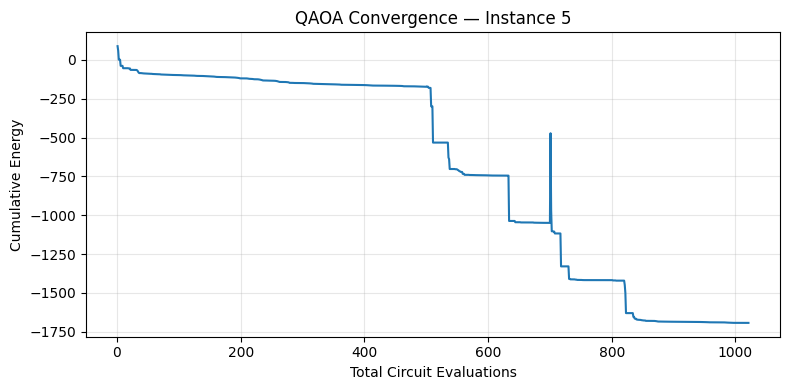

In [67]:
# ── Cumulative Objective Convergence ──
import matplotlib.pyplot as plt
import csv

non_trivial = [cr for cr in cluster_results if cr['convergence']]
if not non_trivial:
    print("No convergence data (all clusters trivial or hardware-optimized)")
else:
    # Build a sequential trace: clusters optimized one after another
    # x = cumulative circuit evaluations, y = cumulative energy (running min per cluster)
    x_evals = []
    y_energy = []
    cumulative_evals = 0
    settled_energy = 0.0

    for cr in non_trivial:
        best_restart = min(cr['convergence'], key=lambda x: x[1][-1] if x[1] else float('inf'))
        trace = best_restart[1]

        curr_min = float('inf')
        for e in trace:
            cumulative_evals += 1
            curr_min = min(curr_min, e)
            x_evals.append(cumulative_evals)
            y_energy.append(settled_energy + curr_min)

        settled_energy += curr_min

    # Save to CSV
    conv_csv = f"convergence_{selected_id}.csv"
    with open(conv_csv, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['circuit_evaluation', 'energy'])
        for x, y in zip(x_evals, y_energy):
            writer.writerow([x, round(y, 4)])
    print(f"Saved convergence data to {conv_csv}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x_evals, y_energy, color='tab:blue', linewidth=1.5)
    ax.set_title(f"QAOA Convergence — Instance {selected_id}")
    ax.set_xlabel("Total Circuit Evaluations")
    ax.set_ylabel("Cumulative Energy")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import math
import time
import json
import warnings
from itertools import permutations
from collections import defaultdict

# ── Qiskit core & simulator imports ──
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer.primitives import EstimatorV2 as AerEstimator, SamplerV2 as AerSampler
from scipy.optimize import minimize

warnings.filterwarnings('ignore')

# ── Configuration Flags ──
USE_REAL_HARDWARE = False   # True = run on IBM QPU
USE_AER_FOR_OPT   = True     # True = optimize on simulator (fast), false = optimize on QPU (Session)
USE_GPU_AER       = False     # True = try GPU-accelerated Aer; falls back to CPU if unavailable
                              # Requires: pip install qiskit-aer-gpu-cu11>=0.17
                              # (works on both CUDA 11 & 12 — the CUDA 12 package lacks a Qiskit 2.0 build)

# ── GPU Aer Options (shared across estimator & sampler) ──
_aer_gpu_options = {}
if USE_GPU_AER:
    try:
        from qiskit_aer import AerSimulator
        from qiskit import QuantumCircuit as _QC
        # Run a trivial 1-qubit circuit to verify GPU actually works
        # (AerSimulator init succeeds even without GPU — the error comes at runtime)
        _test_sim = AerSimulator(method='statevector', device='GPU')
        _test_qc = _QC(1); _test_qc.h(0); _test_qc.save_statevector()
        _test_sim.run(_test_qc).result()
        del _test_sim, _test_qc
        _aer_gpu_options = {'backend_options': {'device': 'GPU', 'method': 'statevector'}}
        print("Aer: GPU backend verified")
    except Exception as e:
        _aer_gpu_options = {}
        print(f"Aer GPU unavailable ({e}), falling back to CPU")

# ── Hardware Configuration ──
if USE_REAL_HARDWARE:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, Session, EstimatorV2
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    # First time only (run ONCE, then comment out)
    # QiskitRuntimeService.save_account(
    #     token="YOUR_IBM_QUANTUM_API_TOKEN",
    #     instance="YOUR_CRN_OR_INSTANCE_NAME",
    #     name="my_account",
    #     set_as_default=True,
    #     overwrite=True
    # )

    service = QiskitRuntimeService(name="my_account")
    backend = service.least_busy(min_num_qubits=16, operational=True)
    pm = generate_preset_pass_manager(optimization_level=2, backend=backend, translation_method="translator")
    print(f"Connected to: {backend.name}")
else:
    backend = None
    pm = None

# ── Utility Functions ──
def euclidean_distance(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

def build_distance_matrix(nodes):
    n = len(nodes)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i,j] = euclidean_distance(nodes[i], nodes[j])
    return D

def expectation_from_counts(counts, hamiltonian):
    """Compute <H> manually from counts (needed if optimizing on QPU)."""
    total = sum(counts.values())
    if total == 0:
        return 0.0
    exp_val = 0.0
    for pauli, coeff in zip(hamiltonian.paulis, hamiltonian.coeffs):
        label = pauli.to_label()
        z_positions = [i for i, c in enumerate(label) if c == 'Z']
        if not z_positions:
            exp_val += coeff.real
            continue
        term_exp = 0.0
        for bitstring, count in counts.items():
            eigenvalue = 1
            for pos in z_positions:
                eigenvalue *= (-1) ** int(bitstring[pos])
            term_exp += eigenvalue * count / total
        exp_val += coeff.real * term_exp
    return float(np.real(exp_val))


In [ ]:
# ── Phase 1: Sweep Algorithm (Classical Clustering) ──

def sweep_decomposition(nodes, Nv, C, n_angles=16):
    """Cluster customers by polar angle from depot, trying multiple starting angles.
    Picks the best rotation using nearest-neighbor TSP estimate (scalable)."""
    depot = nodes[0]
    D_local = build_distance_matrix(nodes)

    # Precompute polar angles for all customers
    customer_angles = []
    for i in range(1, len(nodes)):
        angle = math.atan2(nodes[i][1] - depot[1], nodes[i][0] - depot[0])
        customer_angles.append((i, angle))

    best_clusters = None
    best_cost = float('inf')

    for k in range(n_angles):
        offset = 2 * math.pi * k / n_angles

        # Sort by shifted angle
        shifted = sorted(customer_angles,
                         key=lambda x: (x[1] - offset) % (2 * math.pi))

        # Pack into clusters respecting capacity
        clusters = []
        for start in range(0, len(shifted), C):
            if len(clusters) < Nv:
                chunk = shifted[start : start + C]
                clusters.append([c[0] for c in chunk])

        # Evaluate with nearest-neighbor TSP heuristic — O(n²) per cluster
        cost = 0
        for cluster in clusters:
            if len(cluster) == 1:
                cost += 2 * D_local[0, cluster[0]]
            else:
                visited = []
                current = 0  # start at depot
                remaining = set(cluster)
                while remaining:
                    nearest = min(remaining, key=lambda c: D_local[current, c])
                    cost += D_local[current, nearest]
                    current = nearest
                    remaining.remove(nearest)
                cost += D_local[current, 0]  # return to depot

        if cost < best_cost:
            best_cost = cost
            best_clusters = clusters

    return best_clusters

def clarke_wright_clusters(nodes, Nv, C):
    """Cluster customers using Clarke & Wright savings algorithm.
    Returns list of clusters (same format as sweep_decomposition)."""
    n = len(nodes)
    D = build_distance_matrix(nodes)

    # 1. Start: every customer gets its own route
    routes = [[i] for i in range(1, n)]

    # 2. Compute savings for all pairs: s(i,j) = D[0,i] + D[0,j] - D[i,j]
    savings = []
    for i in range(1, n):
        for j in range(i + 1, n):
            s = D[0, i] + D[0, j] - D[i, j]
            if s > 0:
                savings.append((s, i, j))
    savings.sort(reverse=True, key=lambda x: x[0])

    # 3. Greedily merge routes by highest savings
    def find_route(cust):
        for idx, r in enumerate(routes):
            if cust in r:
                return idx
        return -1

    for s, i, j in savings:
        ri, rj = find_route(i), find_route(j)

        # Must be different routes
        if ri == rj:
            continue

        # Both must be at the edge (first or last) of their route
        r_i, r_j = routes[ri], routes[rj]
        if not (r_i[0] == i or r_i[-1] == i):
            continue
        if not (r_j[0] == j or r_j[-1] == j):
            continue

        # Capacity check
        if len(r_i) + len(r_j) > C:
            continue

        # Orient and merge: make i the tail of r_i, j the head of r_j
        if r_i[-1] == i and r_j[0] == j:
            merged = r_i + r_j
        elif r_i[-1] == i and r_j[-1] == j:
            merged = r_i + r_j[::-1]
        elif r_i[0] == i and r_j[0] == j:
            merged = r_i[::-1] + r_j
        elif r_i[0] == i and r_j[-1] == j:
            merged = r_j + r_i
        else:
            continue

        # Apply merge
        for idx in sorted([ri, rj], reverse=True):
            routes.pop(idx)
        routes.append(merged)

    # 4. If too many routes remain, force-merge the cheapest pairs
    while len(routes) > Nv:
        best_cost, best_pair = float('inf'), None
        for a in range(len(routes)):
            for b in range(a + 1, len(routes)):
                if len(routes[a]) + len(routes[b]) <= C:
                    cost = D[routes[a][-1], routes[b][0]] - D[routes[a][-1], 0] - D[0, routes[b][0]]
                    if cost < best_cost:
                        best_cost = cost
                        best_pair = (a, b)
        if best_pair:
            a, b = best_pair
            routes[a] = routes[a] + routes[b]
            routes.pop(b)
        else:
            break

    return routes

def agglomerative_clusters(nodes, Nv, C):
    """Capacitated agglomerative clustering — merges by route cost reduction."""
    n = len(nodes)
    D = build_distance_matrix(nodes)
    clusters = [[i] for i in range(1, n)]

    def nn_cost(cluster):
        """Nearest-neighbor tour cost: depot → cluster → depot."""
        if len(cluster) == 1:
            return 2 * D[0, cluster[0]]
        cost, current, remaining = 0, 0, set(cluster)
        while remaining:
            nxt = min(remaining, key=lambda c: D[current, c])
            cost += D[current, nxt]
            current = nxt
            remaining.remove(nxt)
        return cost + D[current, 0]

    while len(clusters) > 1:
        best_benefit, best_pair = -float('inf'), None

        for a in range(len(clusters)):
            for b in range(a + 1, len(clusters)):
                if len(clusters[a]) + len(clusters[b]) > C:
                    continue
                benefit = nn_cost(clusters[a]) + nn_cost(clusters[b]) - nn_cost(clusters[a] + clusters[b])
                if benefit > best_benefit:
                    best_benefit = benefit
                    best_pair = (a, b)

        if best_pair is None:
            break  # No valid merges (capacity)
        if best_benefit <= 0 and len(clusters) <= Nv:
            break  # No benefit and within vehicle limit

        a, b = best_pair
        clusters[a] = clusters[a] + clusters[b]
        clusters.pop(b)

    return clusters


In [ ]:
def nn_route_cost(cluster, nodes):
    """Nearest-neighbor route cost for a cluster (depot=0)."""
    if not cluster:
        return 0
    route = [0]
    remaining = list(cluster)
    while remaining:
        last = route[-1]
        nearest = min(remaining, key=lambda c: math.sqrt(
            (nodes[last][0]-nodes[c][0])**2 + (nodes[last][1]-nodes[c][1])**2))
        route.append(nearest)
        remaining.remove(nearest)
    # Return to depot
    cost = sum(math.sqrt((nodes[route[i]][0]-nodes[route[i+1]][0])**2 +
                          (nodes[route[i]][1]-nodes[route[i+1]][1])**2)
               for i in range(len(route)-1))
    cost += math.sqrt((nodes[route[-1]][0]-nodes[0][0])**2 +
                       (nodes[route[-1]][1]-nodes[0][1])**2)
    return cost

def two_opt_cost(cluster, nodes):
    """2-opt improved tour cost. O(C²) — scales to any C."""
    if not cluster or len(cluster) <= 1:
        c = cluster[0] if cluster else 0
        return 2 * math.sqrt((nodes[0][0]-nodes[c][0])**2 + (nodes[0][1]-nodes[c][1])**2) if cluster else 0

    def d(a, b):
        return math.sqrt((nodes[a][0]-nodes[b][0])**2 + (nodes[a][1]-nodes[b][1])**2)

    # Start with NN tour
    route = [0]
    remaining = list(cluster)
    while remaining:
        last = route[-1]
        nearest = min(remaining, key=lambda c: d(last, c))
        route.append(nearest)
        remaining.remove(nearest)
    route.append(0)

    # 2-opt improvement
    improved = True
    while improved:
        improved = False
        for i in range(1, len(route) - 2):
            for j in range(i + 1, len(route) - 1):
                old = d(route[i-1], route[i]) + d(route[j], route[j+1])
                new = d(route[i-1], route[j]) + d(route[i], route[j+1])
                if new < old - 1e-10:
                    route[i:j+1] = reversed(route[i:j+1])
                    improved = True

    return sum(d(route[k], route[k+1]) for k in range(len(route)-1))


def refine_clusters_swap(clusters, nodes, C, func):
    """Improve clusters via inter-cluster pairwise swaps."""
    clusters = [list(c) for c in clusters]
    improved = True
    iteration = 0
    
    while improved:
        improved = False
        iteration += 1
        
        for i in range(len(clusters)):
            for j in range(i+1, len(clusters)):
                old_cost = func(clusters[i], nodes) + func(clusters[j], nodes)
                
                # Try swaps: exchange customer a from cluster i with customer b from cluster j
                best_gain = 0
                best_swap = None
                
                for ai, a in enumerate(clusters[i]):
                    for bi, b in enumerate(clusters[j]):
                        # Swap
                        ci_new = clusters[i][:ai] + [b] + clusters[i][ai+1:]
                        cj_new = clusters[j][:bi] + [a] + clusters[j][bi+1:]
                        
                        if len(ci_new) > C or len(cj_new) > C:
                            continue
                        
                        new_cost = func(ci_new, nodes) + func(cj_new, nodes)
                        gain = old_cost - new_cost
                        
                        if gain > best_gain:
                            best_gain = gain
                            best_swap = (ai, bi, ci_new, cj_new)
                
                # Try moves: move customer from larger to smaller cluster
                for ai, a in enumerate(clusters[i]):
                    if len(clusters[j]) < C:
                        ci_new = clusters[i][:ai] + clusters[i][ai+1:]
                        cj_new = clusters[j] + [a]
                        if ci_new:  # don't empty a cluster
                            new_cost = func(ci_new, nodes) + func(cj_new, nodes)
                            gain = old_cost - new_cost
                            if gain > best_gain:
                                best_gain = gain
                                best_swap = (-1, -1, ci_new, cj_new)
                
                for bi, b in enumerate(clusters[j]):
                    if len(clusters[i]) < C:
                        cj_new = clusters[j][:bi] + clusters[j][bi+1:]
                        ci_new = clusters[i] + [b]
                        if cj_new:
                            new_cost = func(ci_new, nodes) + func(cj_new, nodes)
                            gain = old_cost - new_cost
                            if gain > best_gain:
                                best_gain = gain
                                best_swap = (-1, -1, ci_new, cj_new)
                
                if best_swap and best_gain > 1e-10:
                    clusters[i] = best_swap[2]
                    clusters[j] = best_swap[3]
                    improved = True
                    print(f"  Swap iter {iteration}: clusters {i},{j} improved by {best_gain:.2f}")
    
    print(f"  Swap refinement done in {iteration} iterations")
    return clusters


In [ ]:
# ── Phase 2: TSP via QAOA (Quantum Routing) ──

def build_tsp_qubo(cluster_indices, dist_matrix):
    """Build upper-triangular QUBO for TSP (position formulation).
    Variables x[i,s] = 1 if cluster node i is at route position s.
    n customers → n² binary variables / qubits."""
    n = len(cluster_indices)
    N = n * n
    Q = np.zeros((N, N))
    idx = lambda i, s: i * n + s

    # Penalty coefficient (must dominate route costs)
    max_d = max(dist_matrix[a, b]
                for a in [0] + cluster_indices
                for b in [0] + cluster_indices if a != b)
    A = max_d * n * 1.5

    # Constraint: each customer visited exactly once  Σ_s x[i,s] = 1
    for i in range(n):
        for s in range(n):
            Q[idx(i,s), idx(i,s)] -= A
        for s in range(n):
            for t in range(s+1, n):
                Q[idx(i,s), idx(i,t)] += 2 * A

    # Constraint: each position filled by exactly one customer  Σ_i x[i,s] = 1
    for s in range(n):
        for i in range(n):
            Q[idx(i,s), idx(i,s)] -= A
        for i in range(n):
            for j in range(i+1, n):
                Q[idx(i,s), idx(j,s)] += 2 * A

    # Objective: route distance (depot → pos 0, transitions, pos n-1 → depot)
    for i, ci in enumerate(cluster_indices):
        Q[idx(i,0), idx(i,0)]     += dist_matrix[0, ci]   # depot → first
        Q[idx(i,n-1), idx(i,n-1)] += dist_matrix[ci, 0]   # last → depot
        for j, cj in enumerate(cluster_indices):
            if i != j:
                for s in range(n - 1):
                    a, b = idx(i, s), idx(j, s+1)
                    if a <= b:
                        Q[a, b] += dist_matrix[ci, cj]
                    else:
                        Q[b, a] += dist_matrix[ci, cj]
    return Q


def qubo_to_ising(Q):
    """Convert upper-triangular QUBO matrix to a SparsePauliOp Ising Hamiltonian.
    x_k = (1 - Z_k) / 2"""
    n = Q.shape[0]
    constant = 0.0
    h = np.zeros(n)
    J = {}

    for k in range(n):
        constant += Q[k, k] / 2.0
        h[k]     -= Q[k, k] / 2.0

    for k in range(n):
        for l in range(k+1, n):
            if abs(Q[k, l]) > 1e-12:
                constant += Q[k, l] / 4.0
                h[k]     -= Q[k, l] / 4.0
                h[l]     -= Q[k, l] / 4.0
                J[(k, l)] = Q[k, l] / 4.0

    # Build Pauli list  (qiskit little-endian: rightmost char = qubit 0)
    pauli_list = []
    for k in range(n):
        if abs(h[k]) > 1e-12:
            lbl = ['I'] * n
            lbl[n - 1 - k] = 'Z'
            pauli_list.append((''.join(lbl), h[k]))

    for (k, l), coef in J.items():
        if abs(coef) > 1e-12:
            lbl = ['I'] * n
            lbl[n - 1 - k] = 'Z'
            lbl[n - 1 - l] = 'Z'
            pauli_list.append((''.join(lbl), coef))

    if not pauli_list:
        pauli_list = [('I' * n, 0.0)]

    return SparsePauliOp.from_list(pauli_list).simplify(), constant


def decode_bitstring(bitstring, n, cluster_indices, dist_matrix):
    """Decode a measurement bitstring → (ordered_customer_ids, route_distance).
    Returns (None, inf) when the bitstring violates a constraint."""
    bits = [int(b) for b in reversed(bitstring)]
    while len(bits) < n * n:
        bits.append(0)

    x = np.zeros((n, n), dtype=int)
    for i in range(n):
        for s in range(n):
            x[i, s] = bits[i * n + s]

    if not all(x[i, :].sum() == 1 for i in range(n)):
        return None, float('inf')
    if not all(x[:, s].sum() == 1 for s in range(n)):
        return None, float('inf')

    order = [0] * n
    for i in range(n):
        order[int(np.argmax(x[i, :]))] = cluster_indices[i]

    d = dist_matrix[0, order[0]]
    for k in range(n - 1):
        d += dist_matrix[order[k], order[k+1]]
    d += dist_matrix[order[-1], 0]
    return order, d

def solve_tsp_qaoa(cluster_indices, dist_matrix, reps=3, shots=8192, restarts=2, warm_params=None):
    """Solve TSP on one cluster via QAOA.
    - USE_AER_FOR_OPT=True:  optimize on Aer, sample later
    - USE_AER_FOR_OPT=False: optimize on hardware (Session)
    """
    n = len(cluster_indices)
    if n == 1:
        return None, None, 0, 0, 0.0, [], 0.0

    t0 = time.time()

    Q = build_tsp_qubo(cluster_indices, dist_matrix)
    H, offset = qubo_to_ising(Q)
    ansatz_raw = QAOAAnsatz(H, reps=reps).decompose(reps=3)

    gammas = [(k+1)/reps * 0.75 for k in range(reps)]
    betas  = [(1-(k+1)/reps) * 0.75 for k in range(reps)]
    linear_guess = np.array(betas + gammas)

    convergence_history = []

    if USE_AER_FOR_OPT:
        # ── Optimize on Aer simulator ──
        estimator = AerEstimator(options=_aer_gpu_options) if _aer_gpu_options else AerEstimator()
        _eval_log = []
        def cost_func(params):
            val = estimator.run([(ansatz_raw, H, params)]).result()[0].data.evs
            _eval_log.append(float(val))
            return val

        best_params, best_energy = None, float('inf')
        aer_label = "Aer GPU" if _aer_gpu_options else "Aer CPU"
        print(f"    Optimizing on {aer_label} ({restarts} restarts)...")

        for r in range(restarts):
            if r == 0:
                x0 = linear_guess
                init_type = "Linear Ramp"
            elif r == 1 and warm_params is not None and len(warm_params) == ansatz_raw.num_parameters:
                x0 = warm_params.copy()
                init_type = "Warm Start "
            else:
                x0 = np.random.uniform(-np.pi, np.pi, ansatz_raw.num_parameters)
                init_type = "Random     "

            _eval_log.clear()
            res = minimize(cost_func, x0, method='COBYLA', options={'maxiter': 500})
            convergence_history.append((init_type.strip(), list(_eval_log)))
            print(f"      Restart {r} [{init_type}]: Energy = {res.fun:8.2f} | Iters = {res.nfev}")
            if res.fun < best_energy:
                best_energy = res.fun
                best_params = res.x

    else:
        # ── Optimize on real hardware (Session) ──
        ansatz_hw = pm.run(ansatz_raw)
        H_isa = H.apply_layout(ansatz_hw.layout)

        print(f"    Optimizing on {backend.name} (Session)...")

        with Session(backend=backend) as session:
            estimator = EstimatorV2(mode=session)

            def cost_func(params):
                return estimator.run([(ansatz_hw, H_isa, [params])]).result()[0].data.evs

            best_params, best_energy = None, float('inf')

            for r in range(restarts):
                if r == 0:
                    x0 = linear_guess
                    init_type = "Linear Ramp"
                elif r == 1 and warm_params is not None and len(warm_params) == ansatz_hw.num_parameters:
                    x0 = warm_params.copy()
                    init_type = "Warm Start "
                else:
                    x0 = np.random.uniform(-np.pi, np.pi, ansatz_hw.num_parameters)
                    init_type = "Random     "

                res = minimize(cost_func, x0, method='COBYLA', options={'maxiter': 200})
                print(f"      Restart {r} [{init_type}]: Energy = {res.fun:8.2f} | Iters = {res.nfev}")
                if res.fun < best_energy:
                    best_energy = res.fun
                    best_params = res.x

    elapsed = time.time() - t0
    decomposed = ansatz_raw.decompose()
    n_qubits = ansatz_raw.num_qubits
    n_gates = sum(decomposed.count_ops().values())
    return ansatz_raw, best_params, n_qubits, n_gates, elapsed, convergence_history, offset

# ── Instance Library ──

instances = {
    1: {"Nv": 2, "C": 5, "nodes": [(0,0), (-2,2), (-5,8), (2,3)]},
    2: {"Nv": 2, "C": 2, "nodes": [(0,0), (-2,2), (-5,8), (2,3)]},
    3: {"Nv": 3, "C": 2, "nodes": [(0,0), (-2,2), (-5,8), (2,3), (5,7), (2,4), (2,-3)]},
    4: {"Nv": 4, "C": 3, "nodes": [(0,0), (-2,2), (-5,8), (6,3), (4,4), (3,2),
                                     (0,2), (-2,3), (-4,3), (2,3), (2,7), (-2,5), (-1,4)]},
}

In [ ]:
# ── Configuration ──
read_from_file = False
selected_file_id = "instance_1"   # used when read_from_file = True
selected_id = 4                   # used when read_from_file = False

if read_from_file:
    with open('instances_3.json', 'r') as f:
        all_instances = json.load(f)
    config = next((inst for inst in all_instances if inst['instance_id'] == selected_file_id), None)
    assert config is not None, f"Instance '{selected_file_id}' not found in instances.json"
    Nv = config['Nv']
    C  = config['C']
    nodes = [(c['x'], c['y']) for c in config['customers']]
    selected_id = selected_file_id
else:
    config = instances[selected_id]
    Nv = config['Nv']
    C  = config['C']
    nodes = config['nodes']

print(f"Loaded Instance {selected_id}: {len(nodes)-1} customers, {Nv} vehicles, Capacity {C}, Max qubits: {C**2}")


Loaded Instance instance_1: 25 customers, 5 vehicles, Capacity 5, Max qubits: 25


In [ ]:
# 1. Distance matrix
D = build_distance_matrix(nodes)

# 2. Classical Decomposition
clusters = agglomerative_clusters(nodes, Nv, C)
clusters = refine_clusters_swap(clusters, nodes, C, two_opt_cost)
print(f"Clusters: {clusters}\n")

# 3. Optimize QAOA params on simulator (sequential, with warm-starting from cluster 1)
cluster_results = []
first_params = None
total_time = 0

for i, cluster in enumerate(clusters):
    ansatz, best_params, nq, ng, et, conv_hist, ising_offset = solve_tsp_qaoa(
        cluster, D, reps=3, restarts=2, warm_params=first_params
    )
    # Lock in cluster 1's params for all subsequent clusters
    if i == 0 and best_params is not None:
        first_params = best_params.copy()

    cluster_results.append({
        'cluster': cluster, 'ansatz': ansatz, 'params': best_params,
        'nq': nq, 'ng': ng, 'convergence': conv_hist, 'offset': ising_offset
    })
    total_time += et

# 4. Batched sampling (one job for all clusters)
print(f"\n--- Sampling {'on ' + backend.name if USE_REAL_HARDWARE else 'on simulator'} ---")

shots = 8192
pubs = []
non_trivial = []

for i, cr in enumerate(cluster_results):
    if cr['ansatz'] is None:  # trivial 1-customer cluster
        continue
    if USE_REAL_HARDWARE:
        hw_ansatz = pm.run(cr['ansatz'])
        meas = hw_ansatz.measure_all(inplace=False)
    else:
        meas = cr['ansatz'].measure_all(inplace=False)
    bound = meas.assign_parameters(cr['params'])
    pubs.append(bound)
    non_trivial.append(i)

if USE_REAL_HARDWARE:
    sampler = SamplerV2(mode=backend)
else:
    sampler = AerSampler(options=_aer_gpu_options) if _aer_gpu_options else AerSampler()

all_results = sampler.run(pubs, shots=shots).result()

# 5. Decode all results
total_distance = 0
routes = []
max_qubits = 0
total_gates = 0

for i, cr in enumerate(cluster_results):
    cluster = cr['cluster']
    n = len(cluster)

    if cr['ansatz'] is None:
        # Trivial cluster
        route = list(cluster)
        dist = D[0, cluster[0]] * 2
    else:
        # Decode from batched results
        result_idx = non_trivial.index(i)
        counts = all_results[result_idx].data.meas.get_counts()

        best_route, best_dist = None, float('inf')
        for bs in counts:
            r, d = decode_bitstring(bs, n, cluster, D)
            if r is not None and d < best_dist:
                best_dist = d
                best_route = r

        # Brute-force fallback
        if best_route is None:
            for perm in permutations(cluster):
                d = D[0, perm[0]]
                for k in range(len(perm) - 1):
                    d += D[perm[k], perm[k+1]]
                d += D[perm[-1], 0]
                if d < best_dist:
                    best_dist = d
                    best_route = list(perm)

        route = best_route
        dist = best_dist

    full_route = [0] + route + [0]
    routes.append(full_route)
    total_distance += dist
    max_qubits = max(max_qubits, cr['nq'])
    total_gates += cr['ng']
    print(f"  r{i+1}: {', '.join(map(str, full_route))}  |  Distance: {dist:.2f}  |  Qubits: {cr['nq']}")

print(f"\n{'='*40}")
print(f"Instance {selected_id}  —  Total Distance: {total_distance:.2f}")
print(f"Max Qubits: {max_qubits}  |  Total Gates: {total_gates}  |  Time: {total_time:.2f}s")
aer_label = 'Aer GPU' if _aer_gpu_options else 'Aer CPU'
print(f"Backend: {'IBM ' + backend.name if USE_REAL_HARDWARE else aer_label}")


In [ ]:
# ── Cumulative Objective Convergence ──
import matplotlib.pyplot as plt

non_trivial = [cr for cr in cluster_results if cr['convergence']]
if not non_trivial:
    print("No convergence data (all clusters trivial or hardware-optimized)")
else:
    # For each cluster: best restart -> running min -> convert energy to objective (energy + offset)
    best_traces = []
    for cr in non_trivial:
        best_restart = min(cr['convergence'], key=lambda x: x[1][-1] if x[1] else float('inf'))
        trace = best_restart[1]
        offset = cr['offset']
        running_min = []
        curr_min = float('inf')
        for e in trace:
            curr_min = min(curr_min, e)
            running_min.append(curr_min + offset)
        best_traces.append(running_min)

    # Pad and sum across clusters
    max_len = max(len(t) for t in best_traces)
    padded = [t + [t[-1]] * (max_len - len(t)) for t in best_traces]
    total_obj = [sum(padded[c][step] for c in range(len(padded))) for step in range(max_len)]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(total_obj, color='tab:blue', linewidth=2)
    ax.set_title(f"QAOA Cumulative Objective — Instance {selected_id}")
    ax.set_xlabel("Function Evaluation")
    ax.set_ylabel("Objective Value (total route cost)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()